In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import joblib
import os

## Load Dataset

In [15]:
df = pd.read_csv("../data/raw/prescription_tracking_dataset.csv")

df.head()


,patient_id,symptoms,drug_prescribed,date
0,1,muscle pain swelling,Ibuprofen,2024-01-15
1,2,chest infection cough fever,Azithromycin,2023-04-25
2,3,allergy sneezing itching,Cetirizine,2023-12-13
3,4,high cholesterol risk,Atorvastatin,2023-10-30
4,5,acid reflux stomach burn,Pantoprazole,2023-01-16


## Data Cleaning

In [16]:
df = df.dropna()

df['symptoms'] = df['symptoms'].str.lower()

df['date'] = pd.to_datetime(df['date'])

df.head()

,patient_id,symptoms,drug_prescribed,date
0,1,muscle pain swelling,Ibuprofen,2024-01-15
1,2,chest infection cough fever,Azithromycin,2023-04-25
2,3,allergy sneezing itching,Cetirizine,2023-12-13
3,4,high cholesterol risk,Atorvastatin,2023-10-30
4,5,acid reflux stomach burn,Pantoprazole,2023-01-16


In [17]:
df['drug_prescribed'].value_counts()

drug_prescribed
Ibuprofen       324
ORS             323
Metformin       319
Atorvastatin    315
Dolo650         302
Cetirizine      298
Azithromycin    295
Paracetamol     282
Pantoprazole    276
Amoxicillin     266
Name: count, dtype: int64

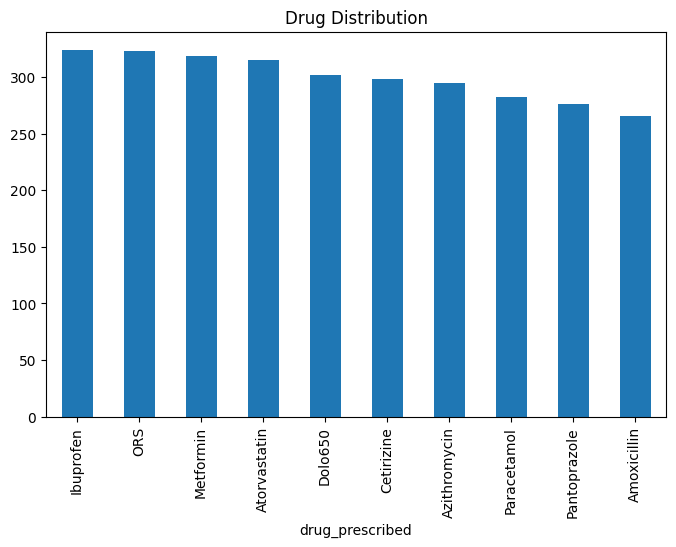

In [18]:
plt.figure(figsize=(8,5))

df['drug_prescribed'].value_counts().plot(kind="bar")

plt.title("Drug Distribution")

plt.show()

## Feature Engineering (TF-IDF)

In [19]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['symptoms'])

y = df['drug_prescribed']

## Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train the Model

In [21]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

## Evaluate Accuracy

In [37]:
pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

 Amoxicillin       1.00      1.00      1.00        53
Atorvastatin       1.00      1.00      1.00        66
Azithromycin       1.00      1.00      1.00        67
  Cetirizine       1.00      1.00      1.00        45
     Dolo650       1.00      1.00      1.00        59
   Ibuprofen       1.00      1.00      1.00        70
   Metformin       1.00      1.00      1.00        67
         ORS       1.00      1.00      1.00        58
Pantoprazole       1.00      1.00      1.00        49
 Paracetamol       1.00      1.00      1.00        66

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



## Test a Sample Prediction

In [45]:
symptom = ["fever cough headache"]

symptom_vec = vectorizer.transform(symptom)

prediction = model.predict(symptom_vec)

print("Recommended Drug:", prediction[0])

Recommended Drug: Paracetamol


## Symptom Matrix for Similarity Search

In [46]:
symptom_matrix = vectorizer.transform(df['symptoms'])

In [47]:
def find_similar_cases(user_symptom, top_n=5):

    user_vec = vectorizer.transform([user_symptom])

    similarity_scores = cosine_similarity(user_vec, symptom_matrix)

    indices = similarity_scores.argsort()[0][-top_n:]

    similar_cases = df.iloc[indices][['symptoms','drug_prescribed']]

    similar_cases = similar_cases.drop_duplicates()

    return similar_cases.reset_index(drop=True)

In [48]:
find_similar_cases("high temperature headache")

,symptoms,drug_prescribed
0,fever headache,Paracetamol


In [49]:
def predict_drug(symptom_text):

    vec = vectorizer.transform([symptom_text])

    prediction = model.predict(vec)

    return prediction[0]

In [50]:
def prescription_analysis(symptoms):

    predicted_drug = predict_drug(symptoms)

    similar_cases = find_similar_cases(symptoms)

    result = {
        "Symptoms Entered": symptoms,
        "Recommended Drug": predicted_drug,
        "Similar Cases": similar_cases
    }

    return result

In [51]:
prescription_analysis("high temperature headache")

{'Symptoms Entered': 'high temperature headache',
 'Recommended Drug': 'Paracetamol',
 'Similar Cases':          symptoms drug_prescribed
 0  fever headache     Paracetamol}

## Save Model

In [31]:
joblib.dump(model,"../models/prescription_model.pkl")

joblib.dump(vectorizer,"../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']